# Imports

In [181]:
# Main Packages
import pandas as pd
import numpy as np

# Graphing
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Low Pass Filter
from scipy.signal import savgol_filter

# Moving Average Filter
from scipy.ndimage import uniform_filter1d

# Filter Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Kalman Filter
from filterpy.common import Q_discrete_white_noise
from filterpy.kalman import predict, update, KalmanFilter

# Disable Warnings
import warnings
warnings.filterwarnings("ignore")

# Data Import and Cleaning

In [182]:
Study_no = "MR23-008"
Reactor_num = 712

df_wuxi_offline_MR = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name="Offline Data")
df_wuxi_online = pd.read_excel(r"M:\Zach Hatzenbeller\State_Estimator_Data\State_Estimator_Data.xlsx", sheet_name=f"{Study_no} DCS Data")

df_wuxi_offline_MR.head()

,Datetime,Day,VCC-710,VCC-711,VCC-712,Gluc-710,Gluc-711,Gluc-712,comments
0,2023-02-14 12:25:33,0.000000,0.45,0.400,0.438,5.88,5.83,5.86,changed timestamp to align with raman readings...
1,2023-02-15 11:21:43,0.955671,1.39,0.997,1.060,5.32,5.50,5.34,2023-02-14 12:25:33
2,2023-02-16 11:02:28,1.942303,2.86,2.030,2.440,4.33,4.58,4.42,NaN
3,2023-02-17 11:35:47,2.965440,6.41,5.150,5.880,2.94,3.29,3.04,NaN
4,2023-02-18 09:09:28,3.863831,11.30,9.020,11.400,3.36,3.93,3.37,NaN


# State Estimator 1: Kalman Filter

### Kalman Filter Parameters and Model

In [183]:
feed_conc = 80
gluc_conc = 468
growth_rate = np.array([ 2.08502101e-04,  5.28365806e-03, -1.93946708e-01,  1.11692487e+00])
glcCSR = np.array([0.0007, -0.0203, 0.1823, -0.6264])

def a1(t1, t2, growth_rate):
    return np.exp((t1-t2)*np.polyval(growth_rate,t2))

def a2(t1, t2, growth_rate, glcCSR):
    return np.polyval(glcCSR, t1)*(t1-t2)*a1(t1,t2,growth_rate)

def b1(volume):
    return feed_conc/volume

def b2(volume):
    return gluc_conc/volume

### Optimization

In [184]:
class Optimizer:

    def __init__(self, initial_array, weight, metric = 1):
        self.iterations = 0
        self.initial_array = initial_array
        self.weight = weight
        self.metric = metric

    def objective_func(self, input):
        offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
        offline_time = df_wuxi_offline_MR["Day"].drop(index=12)
        
        initial = np.array([0.55, np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])[0]])
        kf = KalmanFilter(dim_x=2, dim_z=1, dim_u=2)
        kf.x = initial
        kf.Q = Q_discrete_white_noise(dim=2, dt=1, var=abs(input[0]))
        kf.H = np.array([[0,1]])
        kf.P = np.diag([100., 16.])
        kf.R = np.array([[abs(input[1])]])

        u=np.array(df_wuxi_online[[f"{Reactor_num}-FeedA-Daily",f"{Reactor_num}-Glucose-Daily"]])
        zs=np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

        volume=[1800]
        model_x = []
        xs = []
        cov = []
        k_gain = []

        time = np.linspace(0, df_wuxi_online["Day"].max(), len(zs))

        for count, value in enumerate(df_wuxi_online["Day"]):
            if count != 0:
                kf.F = np.array([[a1(value, df_wuxi_online["Day"][count-1], growth_rate), 0],
                                [a2(value, df_wuxi_online["Day"][count-1], growth_rate, glcCSR), 1]]) # type: ignore
                kf.B = np.array([[0, 0],
                                [b1(volume[count-1]), b2(volume[count-1])]])
                new_vol = volume[count-1] + (u[count][0]-u[count-1][0]) + (u[count][1]-u[count-1][1]) - .15
                volume.append(new_vol)
            kf.predict(u[count-1])
            # restructure u matrix to have different time windows
            # create my own frequency so not limited by raman time intervals
            model_x.append(kf.x)
            # if count % 10 == 0:
            kf.update(zs[count])
            xs.append(kf.x)
            cov.append(kf.P)
            k_gain.append(kf.K)

        offline_kalman = np.interp(offline_time,df_wuxi_online["Day"],np.array(xs)[:,1])
        rmse = np.sqrt((offline_val-offline_kalman).sum()**2)
        rmse = mean_squared_error(offline_val, offline_kalman, squared=False)
        kf_diff = np.diff(np.array(xs)[:,1])
        smoothness = np.std(kf_diff[kf_diff<1])
        if self.metric:
            metric = (self.weight*rmse + (1-self.weight)*smoothness)**2
        else:
            metric = (rmse)**2
        if self.iterations % 1000 == 0:
            print("Current Error: ",metric)
        return metric
    
    def objective_func_2(self, input):
        # input = np.clip(input, 0, None)
        offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
        offline_time = df_wuxi_offline_MR["Day"].drop(index=12)
        kf.x = initial
        kf.Q = Q_discrete_white_noise(dim=2, dt=1, var=input[0])
        kf.H = np.array([[0,1]])
        kf.P = np.diag([100., 16.])
        kf.R = np.array([[input[1]]])
        xs = []
        for count, value in enumerate(time):
            xs.append(kf.x)
            kf.predict(u[count-1])
            if count != 0:
                if count % int(input[2]) == 0 and value > input[3]:
                    kf.update(zs[count])
                kf.F = np.array([[a1(value, time[count-1], growth_rate), 0],
                                [a2(value, time[count-1], growth_rate, glcCSR), 1]]) # type: ignore
                kf.B = np.array([[0, 0],
                                [b1(volume[count-1]), b2(volume[count-1])]])
                new_x = np.dot(kf.F, kf.x) + np.dot(kf.B, u[count-1])
                model_x.append(new_x)
        offline_kalman = np.interp(offline_time,time,np.array(xs)[:,1])
        rmse = np.sqrt((offline_val-offline_kalman).sum()**2)
        rmse = mean_squared_error(offline_val, offline_kalman, squared=False)
        kf_diff = np.diff(np.array(xs)[:,1])
        smoothness = np.std(kf_diff[kf_diff<1])
        metric = (self.weight*rmse + (1-self.weight)*smoothness)**2
        return metric
    
    def optimize(self, obj_func):
        constraints = [{"type": "ineq", "fun": self.minzero_constraint}]
        if obj_func == 1:
            res = minimize(
                self.objective_func, 
                self.initial_array, 
                method="SLSQP", 
                constraints=constraints,
                options={'disp': True}
            )
        else:
            res = minimize(
                self.objective_func_2, 
                self.initial_array, 
                method="SLSQP", 
                constraints=constraints,
            )
        return res.x
    
    def minzero_constraint(self, input):
        if (input[0] or input[1] or input[2]) < 0:
            indicator = -1
        else:
            indicator = 1
        return indicator

# Weight closer to 1 will minimize rmse, weight closer to 0 will minimize the smoothness
initial_array = [0,100]
kf_optimize = Optimizer(initial_array, weight=0.5,metric=1)
result = kf_optimize.optimize(obj_func=1)
print(result)

Current Error:  0.47160617948646566
Current Error:  0.4716041072076595
Current Error:  0.471606179486887
Current Error:  0.07770320269559076
Current Error:  0.07303101632150458
Current Error:  0.06798655045458475
Current Error:  0.06484546576860892
Current Error:  0.06330151337589847
Current Error:  0.06305680216928276
Current Error:  0.06392955053812845
Current Error:  0.0660988443424889
Current Error:  0.07024718433826704
Current Error:  0.07738168414084784
Current Error:  0.0883859130482825
Current Error:  0.08838591096034795
Current Error:  0.08838591305121514
Current Error:  0.08836628904636291
Current Error:  0.08836628696167366
Current Error:  0.08836628904929411
Current Error:  0.08826877524450687
Current Error:  0.08826877317589793
Current Error:  0.08826877524743058
Current Error:  0.08779586649341566
Current Error:  0.0877958645017062
Current Error:  0.08779586649630149
Current Error:  0.0857451766311459
Current Error:  0.08574517495260174
Current Error:  0.0857451766338664


### Main Script

Text(0.5, 1.0, 'MR23-008 Glucose Kalman Filter: R712')

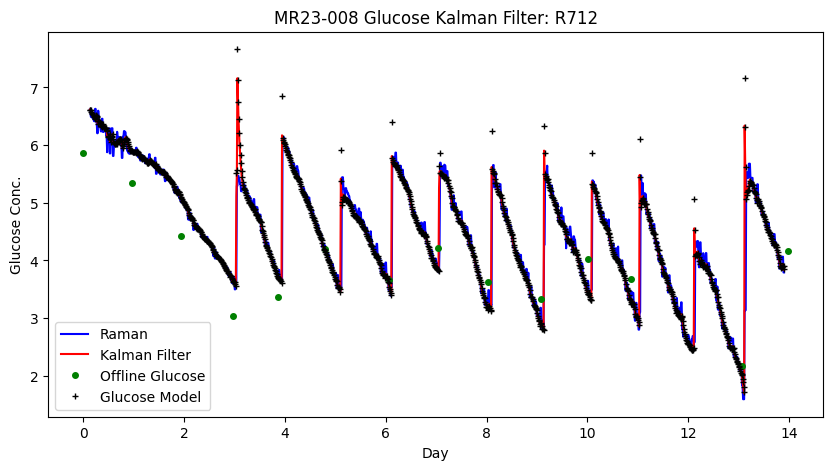

In [185]:
initial = np.array([0.55, np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])[0]])
kf = KalmanFilter(dim_x=2, dim_z=1, dim_u=2)
kf.x = initial
kf.Q = Q_discrete_white_noise(dim=2, dt=1, var=abs(result[0]))
kf.H = np.array([[0,1]])
kf.P = np.diag([100., 16.])
kf.R = np.array([[abs(result[1])]])

u=np.array(df_wuxi_online[[f"{Reactor_num}-FeedA-Daily",f"{Reactor_num}-Glucose-Daily"]])
zs=np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

# np.array(df_wuxi_online[["Datetime",f"{Reactor_num}-FeedA-Daily",f"{Reactor_num}-Glucose-Daily"]].set_index("Datetime").resample("6H").sum())
# np.array(df_wuxi_online[["Datetime",f"{Reactor_num}-Raman-Glucose"]].set_index("Datetime").resample("6H").first())
# np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

volume=[1800]
model_x = []
xs = []
cov = []
k_gain = []

time = np.linspace(0, df_wuxi_online["Day"].max(), len(zs))

for count, value in enumerate(df_wuxi_online["Day"]):
    if count != 0:
        kf.F = np.array([[a1(value, df_wuxi_online["Day"][count-1], growth_rate), 0],
                        [a2(value, df_wuxi_online["Day"][count-1], growth_rate, glcCSR), 1]]) # type: ignore
        kf.B = np.array([[0, 0],
                        [b1(volume[count-1]), b2(volume[count-1])]])
        new_vol = volume[count-1] + (u[count][0]-u[count-1][0]) + (u[count][1]-u[count-1][1]) - .15
        volume.append(new_vol)
    kf.predict(u[count-1])
    # restructure u matrix to have different time windows
    # create my own frequency so not limited by raman time intervals

    # try resetting to offline values everytime they become available and see how much accuracy improves
    model_x.append(kf.x)
    # if count % 10 == 0:
    kf.update(zs[count])
    xs.append(kf.x)
    cov.append(kf.P)
    k_gain.append(kf.K)

fig = plt.figure(figsize=(10,5))
plt.plot(df_wuxi_online["Day"],zs,"b-", label="Raman")
plt.plot(df_wuxi_online["Day"],np.array(xs)[:,1], "r-",label="Kalman Filter")
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR[f"Gluc-{Reactor_num}"],"go", markersize=4, label="Offline Glucose")
plt.plot(df_wuxi_online["Day"],np.array(model_x)[:,1],"k+", markersize=4, label="Glucose Model")

# plt.xlim(0,2)
# plt.ylim(5,7)
plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="best")
plt.title(f"MR23-008 Glucose Kalman Filter: R{Reactor_num}")

# check the starting raman values to ensure they are after the raman batch was started

### Observer Metrics

In [186]:
raman_data = zs
kf_data = np.array(xs)[:,1]
offline = df_wuxi_offline_MR["Day"]
offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
raman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],raman_data),12)
kalman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],kf_data),12)
kalman_diff = np.diff(np.array(xs)[:,1])
raman_diff = np.diff(zs[1:])

raman_mape = round(mean_absolute_percentage_error(offline_val,raman_offline)*100,2)
raman_rmse = round(mean_squared_error(offline_val, raman_offline, squared=False),2)
raman_smooth = round(np.std(raman_diff[raman_diff<1.5]),2)

kf_mape = round(mean_absolute_percentage_error(offline_val,kalman_offline)*100,2)
kf_rmse = round(mean_squared_error(offline_val, kalman_offline, squared=False),2)
kf_smooth = round(np.std(kalman_diff[kalman_diff<1.5]),2)

print("Kalman MAPE: ", kf_mape)
print("Raman MAPE: ", raman_mape)
print("-------------------------")
print("Kalman RMSE: ", kf_rmse)
print("Raman RMSE: ", raman_rmse)
print("-------------------------")
print("Kalman Smoothnes: ", kf_smooth)
print("Raman Smoothness: ", raman_smooth)

Kalman MAPE:  10.61
Raman MAPE:  10.6
-------------------------
Kalman RMSE:  0.46
Raman RMSE:  0.44
-------------------------
Kalman Smoothnes:  0.06
Raman Smoothness:  0.12


# State Estimator 2: Alpha Beta Filter

### Optimization

In [187]:
class AlphaBetaFilter:
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta
        self.filtered_value = None
        self.filtered_velocity = None

    def update(self, measurement):
        if self.filtered_value is None:
            self.filtered_value = measurement
            return self.filtered_value

        if self.filtered_velocity is None:
            self.filtered_velocity = 0.0

        residual = measurement - self.filtered_value
        self.filtered_value += self.alpha * residual
        self.filtered_velocity += self.beta * residual

        return self.filtered_value

class Optimizer:

    def __init__(self, initial_array, weight, metric = 1):
        self.iterations = 0
        self.initial_array = initial_array
        self.weight = weight
        self.metric = metric

    def objective_func(self, input):
        offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
        offline_time = df_wuxi_offline_MR["Day"].drop(index=12)

        filter = AlphaBetaFilter(alpha=input[0], beta=input[1])
        measurements = np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])
        filtered_values = []

        for measurement in measurements:
            filtered_value = filter.update(measurement)
            filtered_values.append(filtered_value)

        offline_ab = np.interp(offline_time,df_wuxi_online["Day"],filtered_values)
        rmse = np.sqrt((offline_val-offline_ab).sum()**2)
        rmse = mean_squared_error(offline_val, offline_ab, squared=False)
        ab_diff = np.diff(filtered_values)
        smoothness = np.std(ab_diff[ab_diff<1])
        if self.metric:
            metric = (self.weight*rmse + (1-self.weight)*smoothness)**2
        else:
            metric = (rmse)**2
        if self.iterations % 1000 == 0:
            print("Current Error: ",metric)
        return metric

    def optimize(self):
        constraints = [{"type": "ineq", "fun": self.minzero_constraint}]
        res = minimize(
            self.objective_func, 
            self.initial_array, 
            # method="SLSQP", 
            constraints=constraints,
            bounds=(
                (0,2),
                (0,2),
            ),
            options={'disp': True}
        )
        return res.x
    
    def minzero_constraint(self, input):
        if (input[0] or input[1] or input[2]) < 0:
            indicator = -1
        else:
            indicator = 1
        return indicator

# Weight closer to 1 will minimize rmse, weight closer to 0 will minimize the smoothness
initial_array = [0.5,0.5]
kf_optimize = Optimizer(initial_array, weight=0.5,metric=1)
result = kf_optimize.optimize()
print(result)

# Cross validation for improving hyperparameters?

Current Error:  0.07031542191850197
Current Error:  0.07031542241579215
Current Error:  0.07031542191850197
Current Error:  0.0692097602997984
Current Error:  0.06920976079025745
Current Error:  0.0692097602997984
Current Error:  0.06702542015997366
Current Error:  0.06702542089643303
Current Error:  0.06702542015997366
Current Error:  1.9925434297528921
Current Error:  0.06552899269643069
Current Error:  0.06552899343694997
Current Error:  0.06552899269643069
Current Error:  1.9925434297493585
Current Error:  0.06417310112144914
Current Error:  0.06417310186742473
Current Error:  0.06417310112144914
Current Error:  1.9925434297335227
Current Error:  0.06294516012264095
Current Error:  0.06294516087161496
Current Error:  0.06294516012264095
Current Error:  1.9925434297528997
Current Error:  0.06184088255205785
Current Error:  0.061840883295457685
Current Error:  0.06184088255205785
Current Error:  1.9925434297521682
Current Error:  0.06086485034892777
Current Error:  0.0608648510689426

### Main Script

Text(0.5, 1.0, 'MR23-008 Glucose Alpha-Beta Filter: R712')

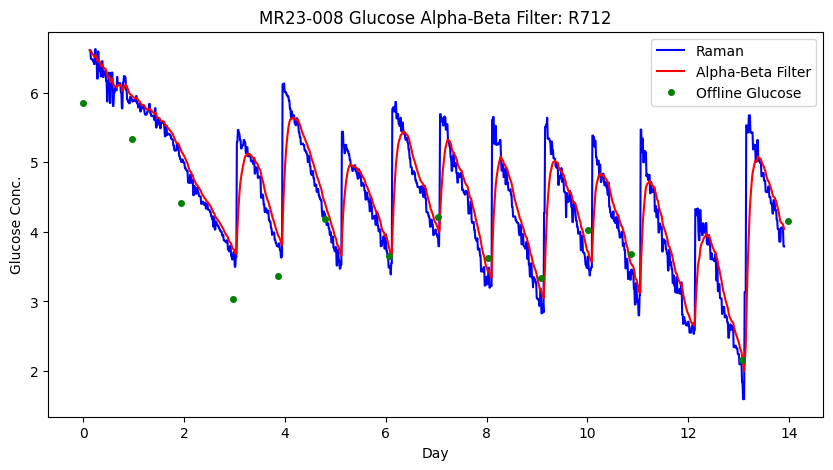

In [188]:
class AlphaBetaFilter:
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta
        self.filtered_value = None
        self.filtered_velocity = None

    def update(self, measurement):
        if self.filtered_value is None:
            self.filtered_value = measurement
            return self.filtered_value

        if self.filtered_velocity is None:
            self.filtered_velocity = 0.0

        residual = measurement - self.filtered_value
        self.filtered_value += self.alpha * residual
        self.filtered_velocity += self.beta * residual

        return self.filtered_value

# Example usage
filter = AlphaBetaFilter(alpha=result[0], beta=result[1])

measurements = np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])
filtered_values = []

for measurement in measurements:
    filtered_value = filter.update(measurement)
    filtered_values.append(filtered_value)

fig = plt.figure(figsize=(10,5))
plt.plot(df_wuxi_online["Day"],measurements,"b-", label="Raman")
plt.plot(df_wuxi_online["Day"],filtered_values, "r-",label="Alpha-Beta Filter")
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR[f"Gluc-{Reactor_num}"],"go", markersize=4, label="Offline Glucose")

# plt.xlim(0,2)
# plt.ylim(5,7)
plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="best")
plt.title(f"MR23-008 Glucose Alpha-Beta Filter: R{Reactor_num}")

### Observer Metrics

In [189]:
raman_data = measurements
ab_data = filtered_values
offline = df_wuxi_offline_MR["Day"]
offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
raman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],raman_data),12)
ab_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],ab_data),12)
ab_diff = np.diff(filtered_values)
raman_diff = np.diff(measurements)

raman_mape = round(mean_absolute_percentage_error(offline_val,raman_offline)*100,2)
raman_rmse = round(mean_squared_error(offline_val, raman_offline, squared=False),2)
raman_smooth = round(np.std(raman_diff[raman_diff<1.5]),2)

ab_mape = round(mean_absolute_percentage_error(offline_val,ab_offline)*100,2)
ab_rmse = round(mean_squared_error(offline_val, ab_offline, squared=False),2)
ab_smooth = round(np.std(ab_diff[ab_diff<1.5]),2)

print("Alpha-Beta MAPE: ", ab_mape)
print("Raman MAPE: ", raman_mape)
print("-------------------------")
print("Alpha-Beta RMSE: ", ab_rmse)
print("Raman RMSE: ", raman_rmse)
print("-------------------------")
print("Alpha-Beta Smoothnes: ", ab_smooth)
print("Raman Smoothness: ", raman_smooth)

Alpha-Beta MAPE:  8.52
Raman MAPE:  10.6
-------------------------
Alpha-Beta RMSE:  0.43
Raman RMSE:  0.44
-------------------------
Alpha-Beta Smoothnes:  0.05
Raman Smoothness:  0.12


# State Estimator 3: Luenberger Observer (Unfinished)

### Main Script

In [190]:
# u=np.array(df_wuxi_online[[f"{Reactor_num}-FeedA-Daily",f"{Reactor_num}-Glucose-Daily"]])
# zs=np.array(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

# def luenberger_observer(A, B, C, Q, R):
#   """
#   Implements a Luenberger observer for a system with one measurement.

#   Args:
#     A: The system matrix.
#     B: The input matrix.
#     C: The measurement matrix.
#     Q: The state covariance matrix.
#     R: The measurement covariance matrix.

#   Returns:
#     The observer gain matrix.
#   """

#   # Calculate the observer gain matrix.
#   L = np.linalg.inv(C.T @ np.linalg.inv(R) @ C + A.T @ np.linalg.inv(Q) @ A) @ A.T @ np.linalg.inv(Q) @ C

#   return L

# def main():
#   volume = [1800]
#   # Define the system parameters.
#   C = np.array([[1, 0]])
#   Q = Q_discrete_white_noise(dim=2, dt=1, var=1)
#   R = np.array([[1]])

#   # Calculate the observer gain matrix.

#   # Simulate the system and the observer.
#   x = np.array([0, 0])
#   y = np.array([0])

#   for count, i in enumerate(df_wuxi_online["Day"]):

#     A = np.array([[a1(value, time[count-1], growth_rate), 0],
#                   [a2(value, time[count-1], growth_rate, glcCSR), 1]]) # type: ignore
#     B = np.array([[0, 0],
#                   [b1(volume[count-1]), b2(volume[count-1])]])
#     new_vol = volume[count-1] + (u[count][0]-u[count-1][0]) + (u[count][1]-u[count-1][1]) - .15
#     volume.append((new_vol))
#     L = luenberger_observer(A, B, C, Q, R)

#     x = A @ x + B @ u
#     y = C @ x + np.random.randn()
#     z = C @ x + L @ (y - C @ x)
#     print(x, z)

# if __name__ == "__main__":
#   main()


# State Estimator 4: Moving Average Estimator

### Optimize

In [191]:
class Optimizer:

    def __init__(self, weight):
        self.iterations = 0
        self.initial_array = initial_array
        self.weight = weight
        self.optimal_rmse = 100
        self.N = 0

    def objective_func(self):
        for n in range(1,100):
            offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
            offline_time = df_wuxi_offline_MR["Day"].drop(index=12)

            N = n
            x = df_wuxi_online[f"{Reactor_num}-Raman-Glucose"]
            y = uniform_filter1d(x, size=N)

            offline_mae = np.interp(offline_time,df_wuxi_online["Day"], y)
            rmse = mean_squared_error(offline_val, offline_mae, squared=False)
            mae_diff = np.diff(y)
            smoothness = np.std(mae_diff[mae_diff<1])
            metric = (self.weight*rmse + (1-self.weight)*smoothness)**2
            if metric < self.optimal_rmse:
                self.optimal_rmse = metric
                self.N = n
            print(metric)

# Weight closer to 1 will minimize rmse, weight closer to 0 will minimize the smoothness
kf_optimize = Optimizer(weight=0.5)
result = kf_optimize.objective_func()
print(kf_optimize.N)

# Cross validation for improving hyperparameters?

0.0737850751247498
0.07449873407936833
0.08042333990997093
0.07329426205892077
0.07054080369149808
0.06693356143875273
0.0640308212906721
0.06233949672281489
0.05890681736105551
0.05832695869083874
0.055169913175915276
0.05426073360432207
0.05335598409287041
0.05271774080619986
0.054795095676175624
0.05408066626454172
0.06016855727539905
0.05900837286493182
0.0669322615920927
0.06565031865100113
0.07514397327751479
0.07364288982988061
0.08369975874756638
0.0818315315070628
0.09203292194959517
0.08967696947909648
0.09945889087956296
0.09686719049673269
0.10598749125522715
0.10297457051917927
0.11170545781370302
0.10855964954370291
0.11701925099412055
0.11428473086065752
0.12214984962826003
0.11954899480948311
0.12696511079075332
0.12465818531919828
0.13100539306079823
0.1286758922572965
0.13480687020109647
0.13245437052086462
0.13837286913242616
0.13612194409989642
0.14181563706228983
0.13986493757789115
0.14522063577769456
0.14341701007754573
0.1484459532159532
0.14666974249651993
0.15

### Main Script

[6.53754501 6.53754501 6.53460536 ... 3.93325896 3.95379839 3.9542861 ]


Text(0.5, 1.0, 'MR23-008 Glucose Alpha-Beta Filter: R712')

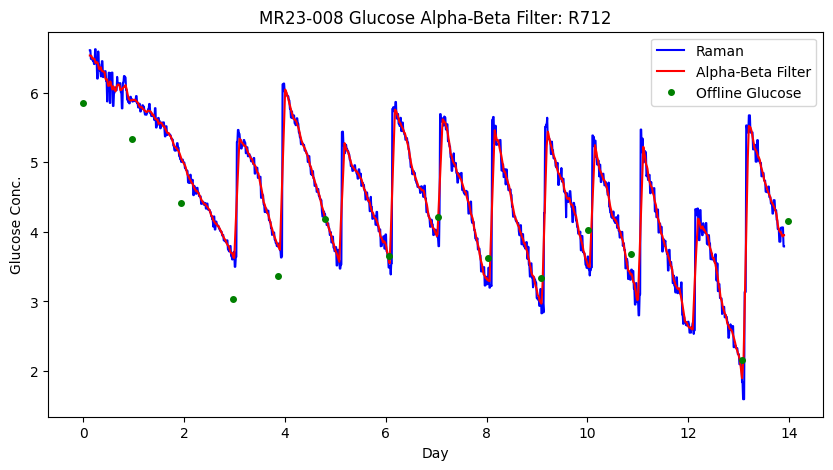

In [192]:
N = 10
x = df_wuxi_online[f"{Reactor_num}-Raman-Glucose"]
y = uniform_filter1d(x, size=N)
print(y)

fig = plt.figure(figsize=(10,5))
plt.plot(df_wuxi_online["Day"],df_wuxi_online[f"{Reactor_num}-Raman-Glucose"],"b-", label="Raman")
plt.plot(df_wuxi_online["Day"],y, "r-",label="Alpha-Beta Filter")
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR[f"Gluc-{Reactor_num}"],"go", markersize=4, label="Offline Glucose")

# plt.xlim(0,2)
# plt.ylim(5,7)
plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="best")
plt.title(f"MR23-008 Glucose Alpha-Beta Filter: R{Reactor_num}")

### Observer Metrics

In [193]:
raman_data = df_wuxi_online[f"{Reactor_num}-Raman-Glucose"]
mae_data = y
offline = df_wuxi_offline_MR["Day"]
offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
raman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],raman_data),12)
mae_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],mae_data),12)
mae_diff = np.diff(y)
raman_diff = np.diff(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

raman_mape = round(mean_absolute_percentage_error(offline_val,raman_offline)*100,2)
raman_rmse = round(mean_squared_error(offline_val, raman_offline, squared=False),2)
raman_smooth = round(np.std(raman_diff[raman_diff<1.5]),2)

mae_mape = round(mean_absolute_percentage_error(offline_val,mae_offline)*100,2)
mae_rmse = round(mean_squared_error(offline_val, mae_offline, squared=False),2)
mae_smooth = round(np.std(mae_diff[mae_diff<1.5]),2)

print("MAE MAPE: ", mae_mape)
print("Raman MAPE: ", raman_mape)
print("-------------------------")
print("MAE RMSE: ", mae_rmse)
print("Raman RMSE: ", raman_rmse)
print("-------------------------")
print("MAE Smoothnes: ", mae_smooth)
print("Raman Smoothness: ", raman_smooth)

MAE MAPE:  9.1
Raman MAPE:  10.6
-------------------------
MAE RMSE:  0.42
Raman RMSE:  0.44
-------------------------
MAE Smoothnes:  0.07
Raman Smoothness:  0.12


# State Estimator 5: Savgol Filter

### Optimization

In [194]:
class Optimizer:

    def __init__(self, weight):
        self.iterations = 0
        self.initial_array = initial_array
        self.weight = weight
        self.optimal_rmse = 100
        self.window_len = 0
        self.polyorder = 0

    def objective_func(self):
        for polyorder in range(1,4):
            for window_len in range(5,40):
                offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
                offline_time = df_wuxi_offline_MR["Day"].drop(index=12)

                filtered_data = savgol_filter(x=df_wuxi_online[f"{Reactor_num}-Raman-Glucose"], window_length=window_len, polyorder=polyorder)

                offline_savgol = np.interp(offline_time,df_wuxi_online["Day"], filtered_data)
                rmse = mean_squared_error(offline_val, offline_savgol, squared=False)
                savgol_diff = np.diff(filtered_data)
                smoothness = np.std(savgol_diff[savgol_diff<1])
                metric = (self.weight*rmse + (1-self.weight)*smoothness)**2
                if metric < self.optimal_rmse:
                    self.optimal_rmse = metric
                    self.window_len = window_len
                    self.polyorder = polyorder
                print(metric)

    # def optimize(self):
    #     constraints = [{"type": "ineq", "fun": self.minzero_constraint}]
    #     res = minimize(
    #         self.objective_func, 
    #         self.initial_array, 
    #         method="SLSQP", 
    #         constraints=constraints,
    #         options={'disp': True}
    #     )
    #     return res.x
    
    # def minzero_constraint(self, input):
    #     if (input[0] or input[1] or input[2]) < 0:
    #         indicator = -1
    #     else:
    #         indicator = 1
    #     return indicator

# Weight closer to 1 will minimize rmse, weight closer to 0 will minimize the smoothness
kf_optimize = Optimizer( weight=0.5)
result = kf_optimize.objective_func()
print(kf_optimize.window_len, kf_optimize.polyorder)

# Cross validation for improving hyperparameters?

0.07222351980598934
0.06848665432982404
0.06597555169352196
0.06158438685369561
0.06039792433513738
0.05693058586733076
0.0559653633811849
0.054632774111512426
0.05416497377840078
0.05700874013253592
0.056972989328246605
0.06458519266128
0.0626392866768916
0.0713821405726467
0.06964876160510698
0.0799088294128874
0.0781892092834695
0.08887460408552524
0.08654646616359819
0.09714207178175334
0.09417781871121123
0.1047360108706045
0.10203279433767895
0.11188334340726415
0.10879503341522613
0.11817402820976186
0.114995699070532
0.12388495882975202
0.12064056242775234
0.12934486424906316
0.12626893789127794
0.1339995687561342
0.13103628263722653
0.13750062299758212
0.13541551143338243
0.084482155536801
0.08868125107031147
0.08236404478941751
0.08417621843394817
0.07992382333839895
0.07917691191697801
0.07717093144427178
0.07448320478437184
0.07330207043706106
0.07055895879120079
0.06953151843531678
0.06543588516329113
0.06649828785738138
0.06443581784401113
0.0644943470581199
0.06154022823

### Main Script

Text(0.5, 1.0, 'MR23-008 Glucose Alpha-Beta Filter: R712')

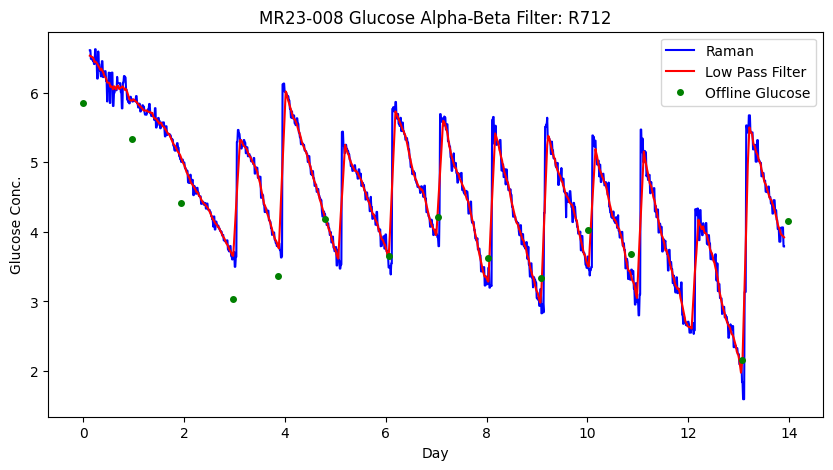

In [195]:
# Filter the data.
filtered_data = savgol_filter(x=df_wuxi_online[f"{Reactor_num}-Raman-Glucose"], window_length=kf_optimize.window_len, polyorder=kf_optimize.polyorder)

fig = plt.figure(figsize=(10,5))
plt.plot(df_wuxi_online["Day"],df_wuxi_online[f"{Reactor_num}-Raman-Glucose"],"b-", label="Raman")
plt.plot(df_wuxi_online["Day"],filtered_data, "r-",label="Low Pass Filter")
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR[f"Gluc-{Reactor_num}"],"go", markersize=4, label="Offline Glucose")

# plt.xlim(0,2)
# plt.ylim(5,7)
plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="best")
plt.title(f"MR23-008 Glucose Alpha-Beta Filter: R{Reactor_num}")

### Observer Metrics

In [196]:
raman_data = df_wuxi_online[f"{Reactor_num}-Raman-Glucose"]
savgol_data = filtered_data
offline = df_wuxi_offline_MR["Day"]
offline_val = np.array(df_wuxi_offline_MR[f"Gluc-{Reactor_num}"].drop(index=12))
raman_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],raman_data),12)
savgol_offline = np.delete(np.interp(offline,df_wuxi_online["Day"],savgol_data),12)
savgol_diff = np.diff(filtered_data)
raman_diff = np.diff(df_wuxi_online[f"{Reactor_num}-Raman-Glucose"])

raman_mape = round(mean_absolute_percentage_error(offline_val,raman_offline)*100,2)
raman_rmse = round(mean_squared_error(offline_val, raman_offline, squared=False),2)
raman_smooth = round(np.std(raman_diff[raman_diff<1.5]),2)

savgol_mape = round(mean_absolute_percentage_error(offline_val,savgol_offline)*100,2)
savgol_rmse = round(mean_squared_error(offline_val, savgol_offline, squared=False),2)
savgol_smooth = round(np.std(savgol_diff[savgol_diff<1.5]),2)

print("Savgol MAPE: ", savgol_mape)
print("Raman MAPE: ", raman_mape)
print("-------------------------")
print("Savgol RMSE: ", savgol_rmse)
print("Raman RMSE: ", raman_rmse)
print("-------------------------")
print("Savgol Smoothnes: ", savgol_smooth)
print("Raman Smoothness: ", raman_smooth)

Savgol MAPE:  8.43
Raman MAPE:  10.6
-------------------------
Savgol RMSE:  0.41
Raman RMSE:  0.44
-------------------------
Savgol Smoothnes:  0.06
Raman Smoothness:  0.12


# Result Summary

In [197]:
df_summary = pd.DataFrame(
    index=["MAPE","RMSE", "Smoothness"],
    columns=["Raman", "Kalman Filter", "Alpha-Beta Filter", "Luenberger Observer", "Moving Average Estimator", "Savgol Filter"],
    data=[[raman_mape, kf_mape, ab_mape, "N/A", mae_mape, savgol_mape],[raman_rmse, kf_rmse, ab_rmse, "N/A", mae_rmse, savgol_rmse],[raman_smooth, kf_smooth, ab_smooth, "N/A", mae_smooth, savgol_smooth]]
)
df_summary.index.name = "Metric"
df_summary

,Raman,Kalman Filter,Alpha-Beta Filter,Luenberger Observer,Moving Average Estimator,Savgol Filter
Metric,,,,,,
MAPE,10.60,10.61,8.52,N/A,9.10,8.43
RMSE,0.44,0.46,0.43,N/A,0.42,0.41
Smoothness,0.12,0.06,0.05,N/A,0.07,0.06
